# Statistical analysis
1. Normality tests , hypothesis tests. grouped by brand
- Shapiro-Wilk
- D`Agostino K^2

In [8]:
import pandas as pd
from scipy.stats import shapiro, normaltest

df_03 = pd.read_parquet('../data/clean_data.parquet')

# We define an empty list
resultados_normalidad = []

# Group by brand
for marca, grupo in df_03.groupby('marcas_cl'):
    # Safety step
    if len(grupo) < 3:
        continue
    # Shapiro test    
    data = grupo['venta_unitaria']
    _, p_val_sw = shapiro(data)
    
    # 2. Agostino test 
    p_val_dag = None
    if len(data) >= 8:
        _, p_val_dag = normaltest(data)
    
    resultados_normalidad.append({
        'Marca': marca,
        'Muestras': len(data),
        'P-Value (Shapiro)': round(p_val_sw, 4),
        'P-Value (K2)': round(p_val_dag, 4) if p_val_dag else "N/A",
        'Es Normal? (α=0.05)': "Sí" if p_val_sw > 0.05 else "No"
    })

# Report
df_reporte = pd.DataFrame(resultados_normalidad)
print(df_reporte)

        Marca  Muestras  P-Value (Shapiro) P-Value (K2) Es Normal? (α=0.05)
0  Alfa Romeo     10809                0.0          N/A                  No
1       Dodge     42909                0.0          N/A                  No
2        Fiat    107115                0.0          N/A                  No
3        Jeep    160966                0.0          N/A                  No
4     Peugeot     80502                0.0          N/A                  No
5         RAM    134020                0.0          N/A                  No


/home/joe/anaconda3/lib/python3.11/site-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


2. Histograms by brand.

/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values

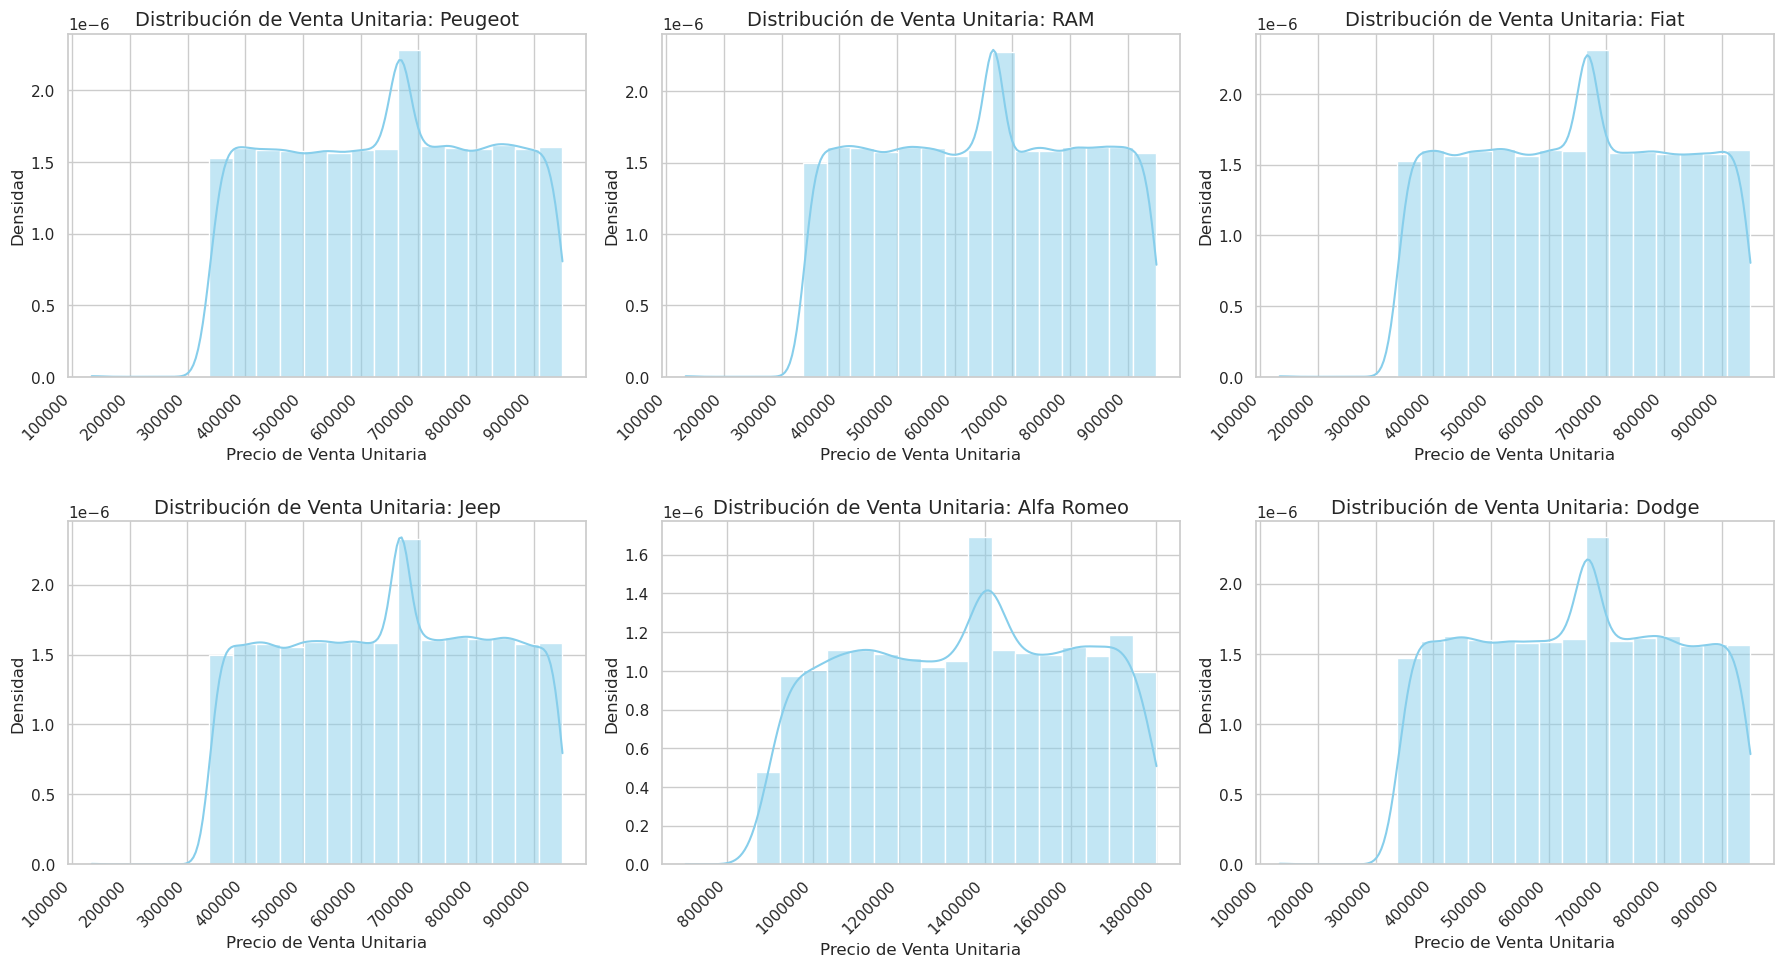

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

marcas = df_03['marcas_cl'].unique()
n_marcas = len(marcas)

ncols = 3
nrows = int(np.ceil(n_marcas / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = axes.flatten() 

# Iterate by brand
for i, marca in enumerate(marcas):
    if i < len(axes):
        datos_marca = df_03[df_03['marcas_cl'] == marca]['venta_unitaria']
        
        sns.histplot(datos_marca, kde=True, ax=axes[i], color='skyblue', stat="density", bins=20)
        
        axes[i].set_title(f'Distribución de Venta Unitaria: {marca}', fontsize=14)
        axes[i].set_xlabel('Precio de Venta Unitaria', fontsize=12)
        axes[i].set_ylabel('Densidad', fontsize=12)
        
        axes[i].ticklabel_format(style='plain', axis='x')
        plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('../graphs/distribucion_venta_unitaria_por_marca.png', dpi=300)
plt.show()

3. Normality tests , hypothesis tests. grouped by brand and then by model
- Shapiro-Wilk

In [10]:
import pandas as pd
from scipy.stats import shapiro

resultados_modelos = []

# Group by brand and model
for (marca, modelo), grupo in df_03.groupby(['marcas_cl', 'modelo']):
    
    if len(grupo) >= 3:
        data = grupo['venta_unitaria']
        stat, p_val = shapiro(data)
        
        resultados_modelos.append({
            'Marca': marca,
            'Modelo': modelo,
            'Muestras': len(data),
            'P-Value': round(p_val, 4),
            'Es Normal?': "Sí" if p_val > 0.05 else "No"
        })

df_modelos = pd.DataFrame(resultados_modelos)
print(df_modelos.sort_values(by='Es Normal?', ascending=False))

         Marca          Modelo  Muestras  P-Value Es Normal?
0   Alfa Romeo          Giulia      3509      0.0         No
12        Jeep  Grand Cherokee     31971      0.0         No
21         RAM             700     33348      0.0         No
20         RAM            2500     33426      0.0         No
19         RAM            1500     33585      0.0         No
18     Peugeot         Manager     20082      0.0         No
17     Peugeot            5008     20127      0.0         No
16     Peugeot            3008     20398      0.0         No
15     Peugeot            2008     19895      0.0         No
14        Jeep        Wrangler     32452      0.0         No
13        Jeep        Renegade     32071      0.0         No
11        Jeep       Gladiator     32276      0.0         No
1   Alfa Romeo         Stelvio      3603      0.0         No
10        Jeep         Compass     32196      0.0         No
9         Fiat           Pulse     26615      0.0         No
8         Fiat          

/home/joe/anaconda3/lib/python3.11/site-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


4. Histograms by model, example for Alfa Romeo.

/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


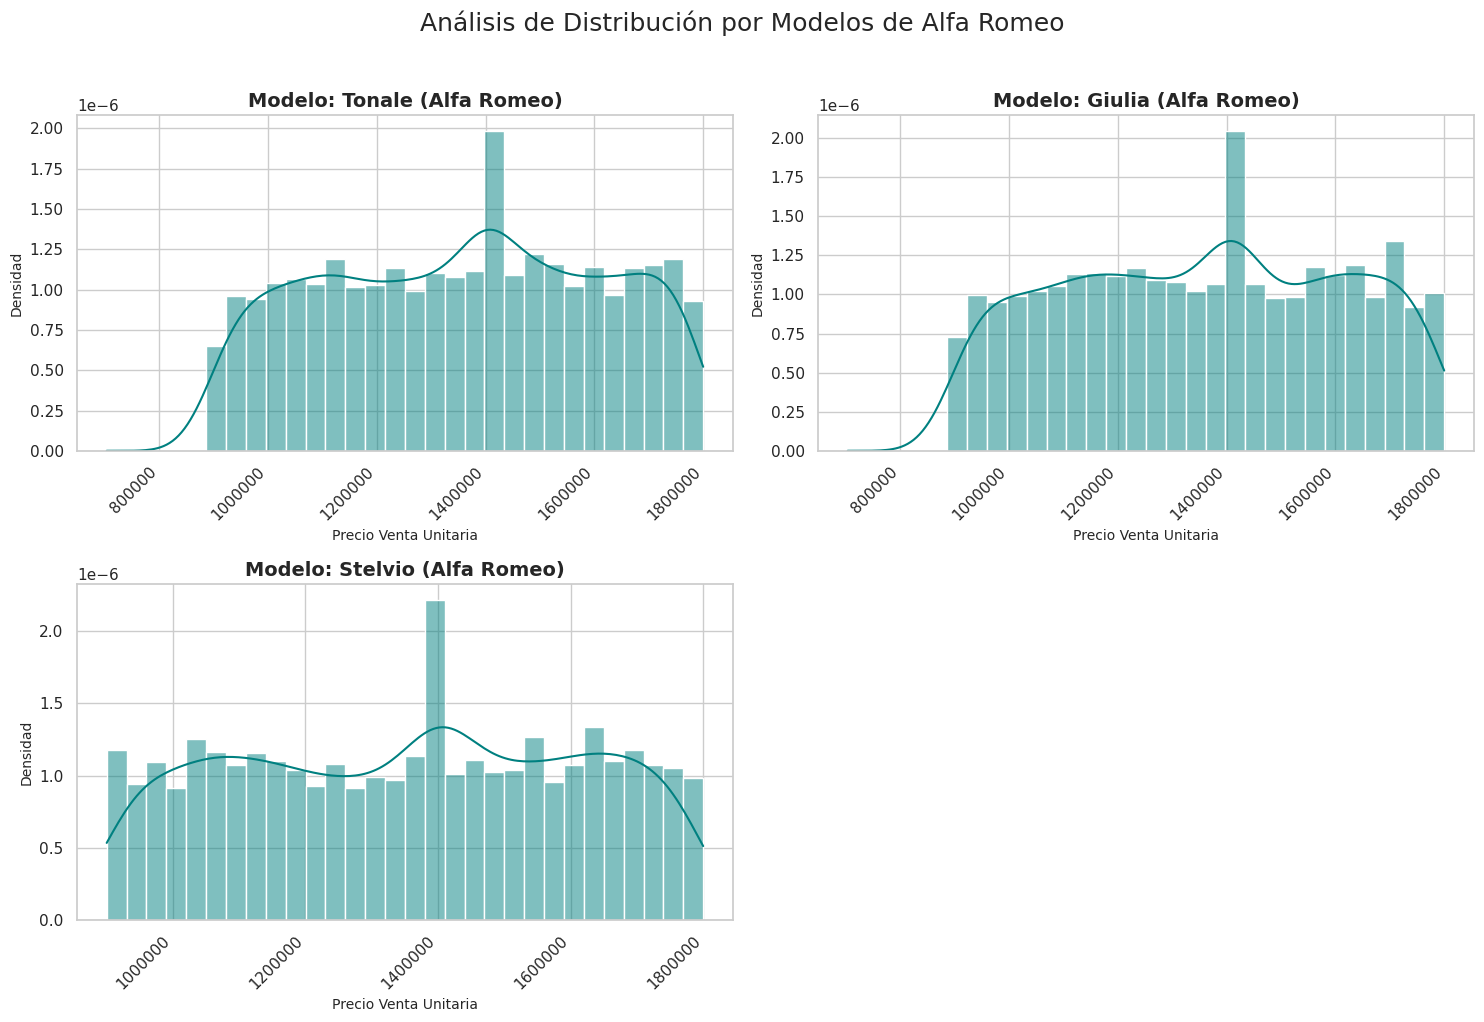

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

marca_objetivo = 'Alfa Romeo'
df_marca = df_03[df_03['marcas_cl'] == marca_objetivo]

modelos = df_marca['modelo'].unique()
n_modelos = len(modelos)

ncols = 2
nrows = int(np.ceil(n_modelos / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

#Iterate by model
for i, modelo in enumerate(modelos):
    if i < len(axes):
        datos_modelo = df_marca[df_marca['modelo'] == modelo]['venta_unitaria']
    
        sns.histplot(datos_modelo, kde=True, ax=axes[i], color='teal', stat="density", bins=30)
        
        axes[i].set_title(f'Modelo: {modelo} ({marca_objetivo})', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Precio Venta Unitaria', fontsize=10)
        axes[i].set_ylabel('Densidad', fontsize=10)
        
        axes[i].ticklabel_format(style='plain', axis='x')
        plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')

# Clean of empty axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Análisis de Distribución por Modelos de {marca_objetivo}', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('../graphs/distribucion_venta_unitaria_por_modelo.png', dpi=300)
plt.show()

5. Correlation matrix.

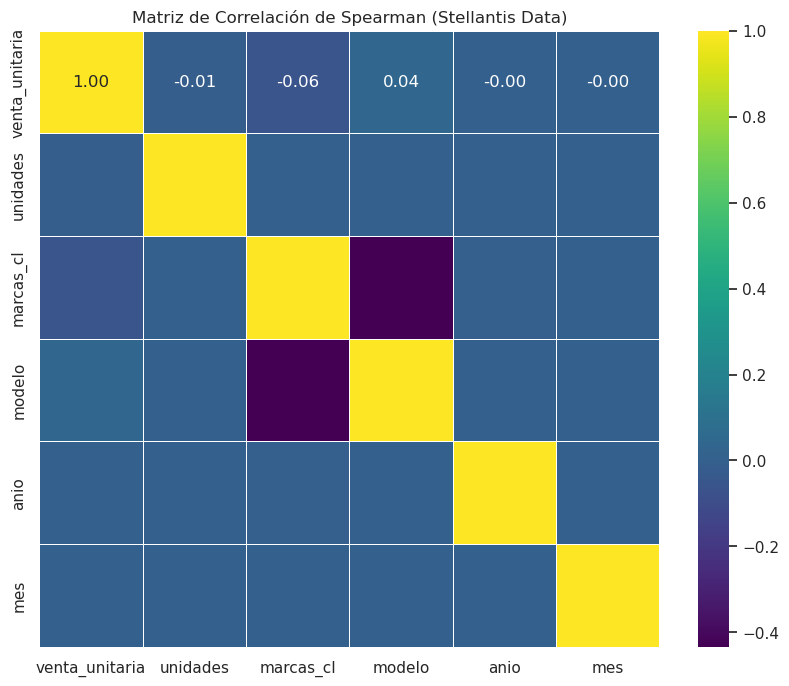

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_corr = df_03.copy()

df_corr['fecha'] = pd.to_datetime(df_corr['fecha'])
df_corr['anio'] = df_corr['fecha'].dt.year
df_corr['mes'] = df_corr['fecha'].dt.month

# Label Encoding
for col in ['marcas_cl', 'modelo']:
    df_corr[col] = df_corr[col].astype('category').cat.codes

# Key columns selection
cols_interes = ['venta_unitaria', 'unidades', 'marcas_cl', 'modelo', 'anio', 'mes']
matriz_spearman = df_corr[cols_interes].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_spearman, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación de Spearman (Stellantis Data)")
plt.savefig('../graphs/matriz de correlacion.png', dpi=300)
plt.show()

In [13]:
#DATA BASE CONNECTION SEETINGS
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

# 1. Load variables from .env
load_dotenv(dotenv_path='../.env')

def get_connection():
    try:
        # 2. Get credentials
        user = os.getenv('DB_USER')
        password = os.getenv('DB_PASS')
        host = os.getenv('DB_HOST')
        port = os.getenv('DB_PORT')
        db = os.getenv('DB_NAME')

        # 3. Create connection engine
        url_conexion = f'postgresql://{user}:{password}@{host}:{port}/{db}'
        engine = create_engine(url_conexion)
        
        print("✅ Conexión establecida con éxito a pgAdmin.")
        return engine
    except Exception as e:
        print(f"❌ Error al conectar: {e}")
        return None

# Execute connection
engine = get_connection()
df_03.drop(columns=['outliers'], inplace=True)

✅ Conexión establecida con éxito a pgAdmin.


In [ ]:
df_03.to_sql('fact_ventas_lake', engine, if_exists='replace', index=False)